In [207]:
import pandas as pd

pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
from typing import List
from pyprojroot import here


sys.path.append(str(here("Scripts")))
from utils import sort_data, club_data_import

In [208]:
data_path = here("Data/FPL_data_untidy.parquet")
club_data_path = here("Data/club_data.parquet")
club_data = pd.read_parquet(club_data_path,
                            engine="pyarrow")
data = pd.read_parquet(data_path,
                       engine='pyarrow')
data.columns = data.columns.str.lower()
data.head()

,name,position,team,xp,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time_player,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,gw,season_id,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,starts,mng_clean_sheets,mng_draw,mng_goals_scored,mng_loss,mng_underdog_draw,mng_underdog_win,mng_win,modified,clearances_blocks_interceptions,defensive_contribution,recoveries,tackles,match_date,kickoff_time_match,opp,gf,ga,sh,sht,corners,yc,rc,fouls,b365_win,b365_draw,b365_loss,b365_o25,b365_u25,b365_ah_line,b365_ah_team,b365_ah_opp
0,Aaron Anselmino,DEF,Chelsea,1.8,0,0,0,0,0.0,774,242,0,0,0.0,0.0,2025-02-14 20:00:00,0,5,0,0,0,0,0,0,0,3,0,0,0,0,0,40,False,0,25,2024-25,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,False,<NA>,<NA>,<NA>,<NA>,2025-02-14,2025-02-14 20:00:00,Brighton,0,3,8,0,9,2,0,15,2.45,3.6,2.7,1.57,2.38,-0.25,2.08,1.73
1,Aaron Anselmino,DEF,Chelsea,0.5,0,0,0,0,0.0,774,252,0,0,0.0,0.0,2025-02-22 17:30:00,0,2,0,0,0,0,0,156,1,2,0,0,82,92,10,40,False,0,26,2024-25,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,False,<NA>,<NA>,<NA>,<NA>,2025-02-22,2025-02-22 17:30:00,Aston Villa,1,2,15,7,3,3,0,16,2.6,3.4,2.63,1.57,2.38,-0.0,1.92,1.98
2,Aaron Anselmino,DEF,Chelsea,1.0,0,0,0,0,0.0,774,268,0,0,0.0,0.0,2025-02-25 20:15:00,0,17,0,0,0,0,0,236,0,4,0,0,29,58,29,40,True,0,27,2024-25,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,False,<NA>,<NA>,<NA>,<NA>,2025-02-25,2025-02-25 20:15:00,Southampton,4,0,19,10,4,1,0,6,1.17,8.0,13.0,1.29,3.75,-2.25,2.0,1.93
3,Aaron Anselmino,DEF,Chelsea,0.5,0,0,0,0,0.0,774,273,0,0,0.0,0.0,2025-03-09 14:00:00,0,11,0,0,0,0,0,325,0,1,0,0,21,52,31,40,True,0,28,2024-25,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,False,<NA>,<NA>,<NA>,<NA>,2025-03-09,2025-03-09 14:00:00,Leicester,1,0,20,7,12,1,0,12,1.18,8.0,12.0,1.33,3.2,-2.0,1.95,1.95
4,Aaron Anselmino,DEF,Chelsea,0.0,0,0,0,0,0.0,774,281,0,0,0.0,0.0,2025-03-16 13:30:00,0,1,0,0,0,0,0,436,0,1,0,0,4,31,27,40,False,0,29,2024-25,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,False,<NA>,<NA>,<NA>,<NA>,2025-03-16,2025-03-16 13:30:00,Arsenal,0,1,8,2,4,3,0,13,4.5,3.6,1.8,1.86,1.92,0.75,1.84,2.06


In [209]:
sum(data.match_date == data.match_date)

127465

In [210]:
sum(data.kickoff_time_player == data.kickoff_time_match)

65348

In [211]:
data.shape

(127465, 72)

In [212]:
data.drop(columns=["kickoff_time_player", "kickoff_time_match"], inplace=True)

In [213]:
data.isna().sum().sum()

np.int64(1444424)

In [214]:
data.isna().mean()[data.isna().mean()>0]

expected_assists                   0.199639
expected_goal_involvements         0.199639
expected_goals                     0.199639
expected_goals_conceded            0.199639
starts                             0.199639
mng_clean_sheets                   0.894661
mng_draw                           0.894661
mng_goals_scored                   0.894661
mng_loss                           0.894661
mng_underdog_draw                  0.894661
mng_underdog_win                   0.894661
mng_win                            0.894661
modified                           0.640780
clearances_blocks_interceptions    0.857349
defensive_contribution             0.857349
recoveries                         0.857349
tackles                            0.857349
b365_o25                           0.000463
b365_u25                           0.000463
dtype: float64

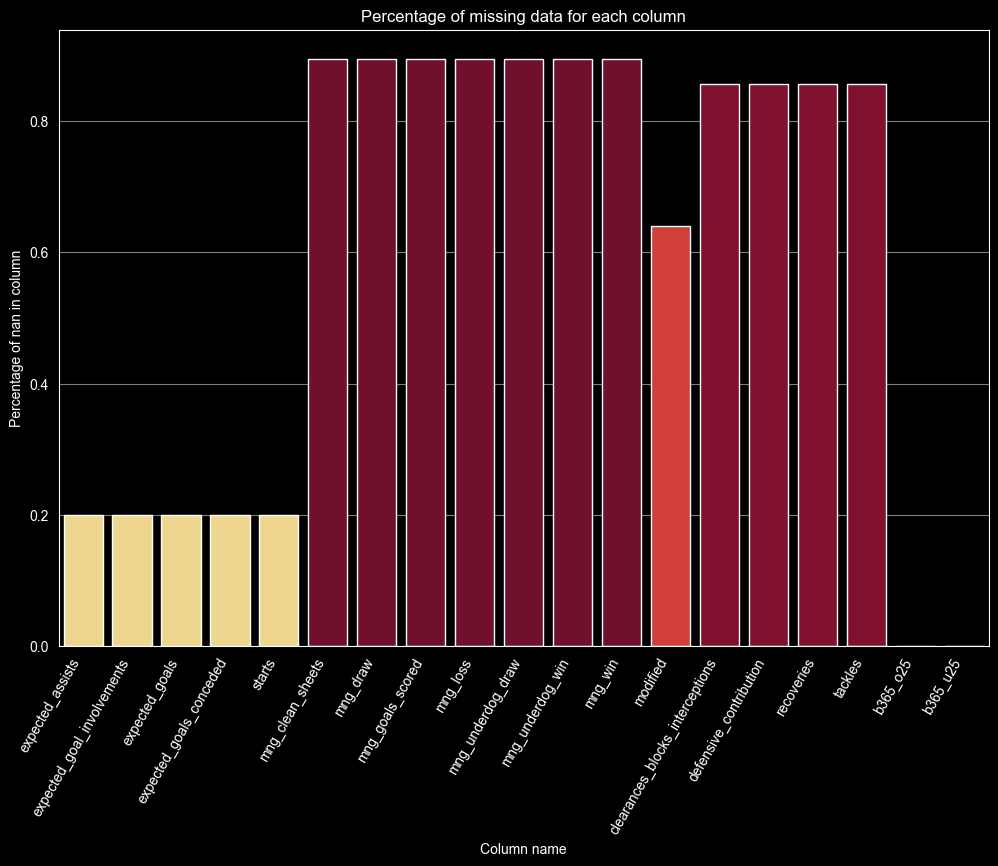

In [215]:
plt.figure(figsize=(12, 8))
s = data.isna().mean()
s = s[s > 0]

sns.barplot(x=s.index, y=s, hue=s.index, legend=False, palette=list(plt.cm.YlOrRd((s / s.max()))))
plt.xlabel("Column name")
plt.ylabel("Percentage of nan in column")
plt.title("Percentage of missing data for each column")

plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', alpha=0.5);

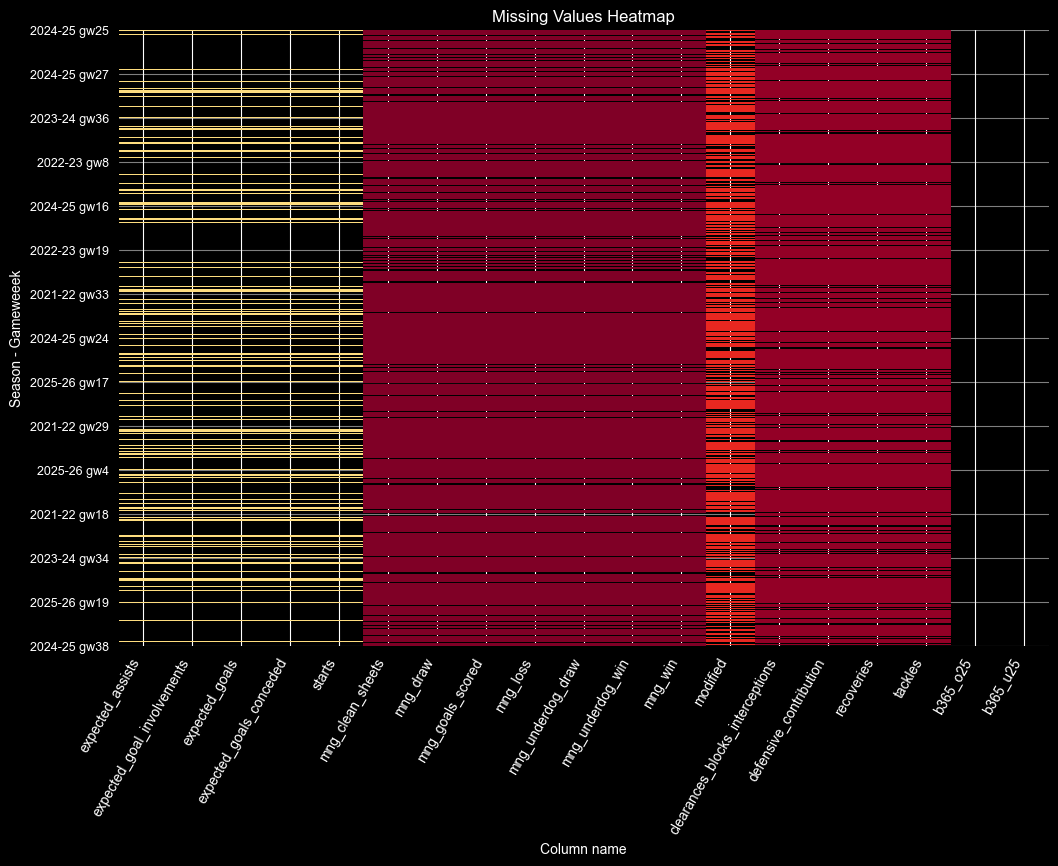

In [216]:
d = data.loc[:, data.isna().any()]
labels = data["season_id"].astype(str) + " gw" + data["gw"].astype(str)
plt.figure(figsize=(12, 8))
sns.heatmap(d.isna() * d.isna().mean(), mask=d.notna(), cmap='YlOrRd',
            cbar=False, yticklabels=False)

plt.title("Missing Values Heatmap")
plt.xticks(rotation=60, ha='right')

n_ticks = 15
y_positions = np.linspace(0, d.shape[0]-1, n_ticks)

plt.yticks(y_positions, labels.iloc[y_positions.astype(int)], fontsize=9)
plt.ylabel("Season - Gameweeek")
plt.xlabel("Column name")

plt.grid(axis='y', alpha=0.5)

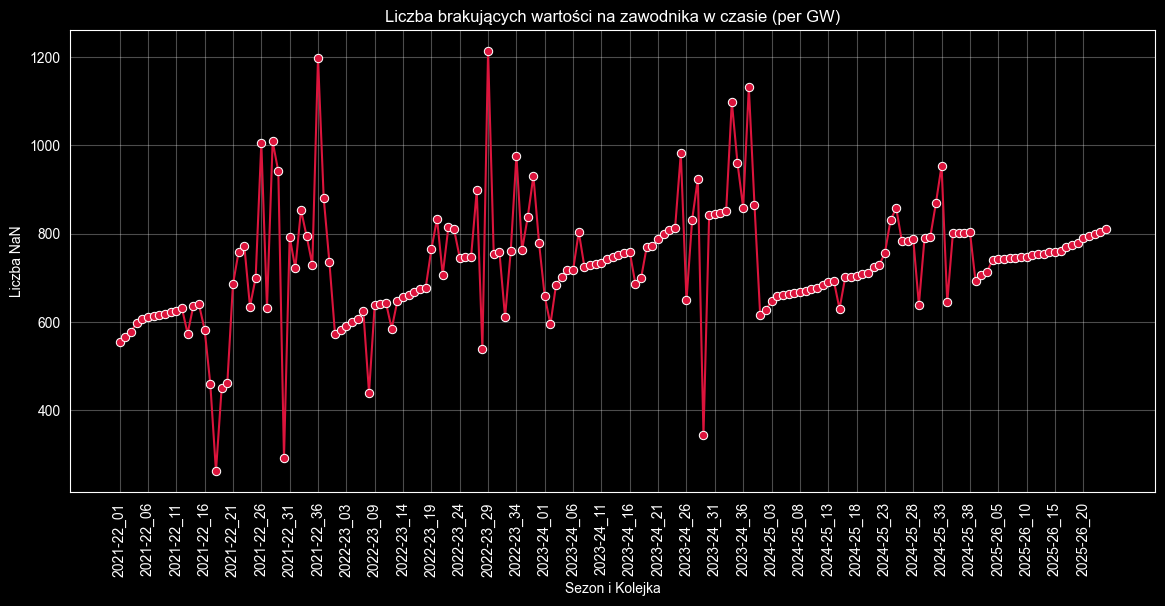

In [217]:
plt.figure(figsize=(14, 6))

sns.lineplot(data=data.isna().sum(axis=1).groupby(data['season_id'].astype(str) + "_" + data['gw'].astype(str).str.zfill(2)).count(),
             color='crimson', marker='o')

plt.title("Liczba brakujących wartości na zawodnika w czasie (per GW)")
plt.ylabel("Liczba NaN")
plt.xlabel("Sezon i Kolejka")

plt.xticks(range(0, data[['season_id', 'gw']].drop_duplicates().shape[0], 5), rotation=90)

plt.grid(alpha=0.3)

In [218]:
data_w_nan = data.copy()

In [219]:
s[s<.1]

b365_o25    0.000463
b365_u25    0.000463
dtype: float64

In [220]:
data_w_nan.loc[data_w_nan[s[s<.1].index].isna().any(axis=1), s[s<.1].index].head()

,b365_o25,b365_u25
5473,<NA>,<NA>
11211,<NA>,<NA>
13759,<NA>,<NA>
14157,<NA>,<NA>
17939,<NA>,<NA>


In [221]:
bet_nan_idx = data_w_nan.loc[data_w_nan[s[s<.1].index].isna().any(axis=1), s[s<.1].index].index

In [222]:
bet_nan_idx

Index([  5473,  11211,  13759,  14157,  17939,  22300,  22369,  22823,  23728,
        31778,  32495,  33351,  34022,  37245,  37907,  38220,  38296,  39803,
        40431,  47432,  47877,  49281,  50339,  51928,  52142,  53149,  55794,
        56924,  59404,  60166,  60759,  61360,  62912,  63878,  64617,  67653,
        68957,  71681,  77480,  81930,  82436,  85296,  85934,  88332,  91499,
        95933,  99283, 100150, 101317, 104232, 105367, 106222, 107136, 108277,
       109475, 110428, 110998, 118536, 126652],
      dtype='int64')

In [223]:
data_w_nan.iloc[bet_nan_idx].loc[:, ["match_date", "team"]]

,match_date,team
5473,2021-12-19,Newcastle
11211,2021-12-19,Man City
13759,2021-12-19,Man City
14157,2021-12-19,Man City
17939,2021-12-19,Newcastle
22300,2021-12-19,Newcastle
22369,2021-12-19,Man City
22823,2021-12-19,Man City
23728,2021-12-19,Man City
31778,2021-12-19,Newcastle


In [224]:
club_data_nan = club_data[club_data.match_date.isin(data_w_nan.iloc[bet_nan_idx].match_date) & club_data.team.isin(data_w_nan.iloc[bet_nan_idx].team)]
club_data_nan


,kickoff_time,season_id,team,opp,gf,ga,sh,sht,corners,yc,rc,fouls,b365_win,b365_draw,b365_loss,b365_o25,b365_u25,b365_ah_line,b365_ah_team,b365_ah_opp,was_home,match_date
333,2021-12-19 14:00:00,2021-22,Man City,Newcastle,4,0,18,7,6,2,0,6,1.18,7.5,13.0,<NA>,<NA>,-2.0,1.84,2.06,False,2021-12-19
334,2021-12-19 14:00:00,2021-22,Newcastle,Man City,0,4,5,1,3,1,0,9,13.0,7.5,1.18,<NA>,<NA>,2.0,2.06,1.84,True,2021-12-19


In [225]:
raw_club_data = club_data_import(season_list=data_w_nan.season_id.unique().tolist())


C:\Users\russa\PycharmProjects\FPL_Points_Predicting\FPL-Points-Predictions\Scripts\utils.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs = []
C:\Users\russa\PycharmProjects\FPL_Points_Predicting\FPL-Points-Predictions\Scripts\utils.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs = []


In [226]:
imputation_bookie_raw = raw_club_data.loc[(raw_club_data.season_id.isin(club_data_nan.season_id)) &
                  (raw_club_data.HomeTeam.isin(club_data_nan.team) & raw_club_data.AwayTeam.isin(club_data_nan.opp)),
                  ["Avg>2.5", "Avg<2.5", "HomeTeam"]]
imputation_bookie_raw

,Avg>2.5,Avg<2.5,HomeTeam
408,1.65,2.26,Newcastle
621,1.71,2.17,Man City


In [227]:
data_w_nan.loc[(data_w_nan[s[s<.1].index].isna().any(axis=1)) &
               (data_w_nan.team=="Newcastle"),
                s[s<.1].index[0]] = imputation_bookie_raw["Avg>2.5"].values[0]

data_w_nan.loc[(data_w_nan[s[s<.1].index].isna().any(axis=1)) &
               (data_w_nan.team=="Man City"),
                s[s<.1].index[0]] = imputation_bookie_raw["Avg>2.5"].values[1]

data_w_nan.loc[(data_w_nan[s[s<.1].index].isna().any(axis=1)) &
               (data_w_nan.team=="Newcastle"),
                s[s<.1].index[1]] = imputation_bookie_raw["Avg<2.5"].values[0]

data_w_nan.loc[(data_w_nan[s[s<.1].index].isna().any(axis=1)) &
               (data_w_nan.team=="Man City"),
                s[s<.1].index[1]] = imputation_bookie_raw["Avg<2.5"].values[1]


In [228]:
data_w_nan[s[s<.1].index].isna().sum()

b365_o25    0
b365_u25    0
dtype: int64

In [229]:
data[s[s < .1].index] = data_w_nan[s[s < .1].index]

In [230]:
data[s[s<.1].index].isna().sum()

b365_o25    0
b365_u25    0
dtype: int64

In [231]:
data_w_nan.drop(columns=data_w_nan[s[s>.8].index].columns.to_list(), inplace=True)

In [232]:
data_w_nan = data_w_nan.assign(
    nan_flag = np.where(data_w_nan[s[s < 0.2].index.to_list()].isna().any(axis=1), 1, 0)
)

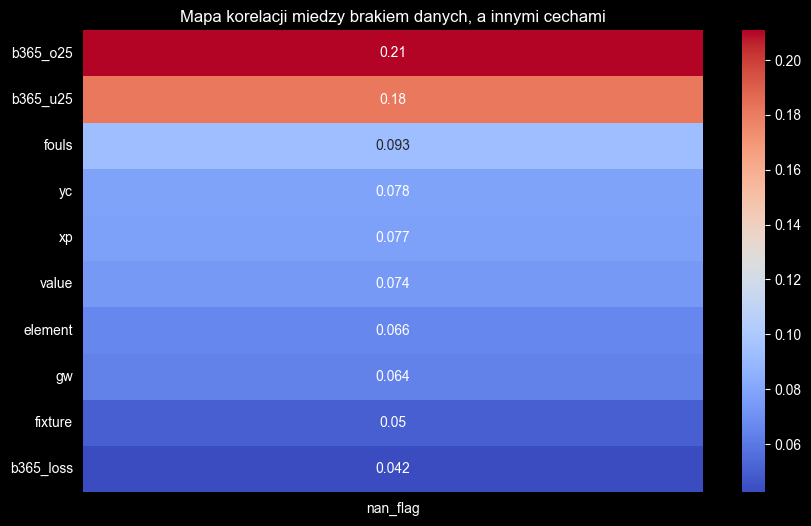

In [233]:
plt.figure(figsize=(10, 6))
plt.title("Mapa korelacji miedzy brakiem danych, a innymi cechami")
sns.heatmap(pd.DataFrame(data_w_nan.drop(columns=data_w_nan.select_dtypes(include=["object", "string"])).corr("pearson")\
                         .nan_flag.apply(np.abs).sort_values(ascending=False).dropna().head(11)).drop(["nan_flag"], axis=0),
            annot=True,
            cmap="coolwarm");

In [234]:
data_w_nan.position.unique()

<ArrowStringArray>
['DEF', 'FWD', 'MID', 'GK', 'GKP', 'AM']
Length: 6, dtype: string

In [235]:
data_w_nan.loc[data_w_nan.position=="GKP", "name"].count()

np.int64(101)

In [236]:
data_w_nan.loc[data_w_nan.position=="GKP"].head()

,name,position,team,xp,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,gw,season_id,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,starts,modified,match_date,opp,gf,ga,sh,sht,corners,yc,rc,fouls,b365_win,b365_draw,b365_loss,b365_o25,b365_u25,b365_ah_line,b365_ah_team,b365_ah_opp,nan_flag
451,Aaron Ramsdale,GKP,Arsenal,2.5,0,0,16,0,0.0,559,365,2,0,3.0,30.2,90,14,0,0,0,0,3,1490905,0,2,0,2,-51351,8030,59381,51,False,0,37,2021-22,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2022-05-16,Newcastle,0,2,11,2,8,3,0,8,1.83,3.6,4.33,1.9,2.0,-0.5,1.87,2.03,1
2531,Adrián San Miguel del Castillo,GKP,Liverpool,1.0,0,0,0,0,0.0,223,366,0,0,0.0,0.0,0,16,0,0,0,0,0,16141,2,1,0,0,-35,38,73,43,False,0,37,2021-22,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2022-05-17,Southampton,2,1,24,5,9,0,0,6,1.33,5.5,7.5,1.44,2.75,-1.5,1.97,1.93,1
3593,Alex McCarthy,GKP,Southampton,-0.6,0,0,15,0,0.0,334,366,2,0,1.4,14.4,90,11,0,0,0,0,3,104479,2,1,0,2,-816,155,971,43,True,0,37,2021-22,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2022-05-17,Liverpool,1,2,4,2,1,2,0,6,7.5,5.5,1.33,1.44,2.75,1.5,1.93,1.97,1
5226,Alisson Ramses Becker,GKP,Liverpool,5.4,0,0,15,0,0.0,231,366,1,0,1.0,9.6,90,16,0,0,0,0,1,828151,2,1,0,2,-2235,13994,16229,61,False,0,37,2021-22,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2022-05-17,Southampton,2,1,24,5,9,0,0,6,1.33,5.5,7.5,1.44,2.75,-1.5,1.97,1.93,1
5606,Alphonse Areola,GKP,West Ham,-1.0,0,0,0,0,0.0,489,369,0,0,0.0,0.0,0,12,0,0,0,0,0,65140,2,2,0,0,-90,233,323,47,True,0,37,2021-22,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2022-05-15,Man City,2,2,6,2,4,3,0,9,7.5,5.0,1.4,1.53,2.5,1.5,1.81,2.09,1


In [237]:
data_w_nan.loc[data_w_nan.position=="GKP"].goals_scored.sum()

np.int64(0)

In [238]:
data_w_nan.position = data_w_nan.position.replace({"GKP" : "GK"})

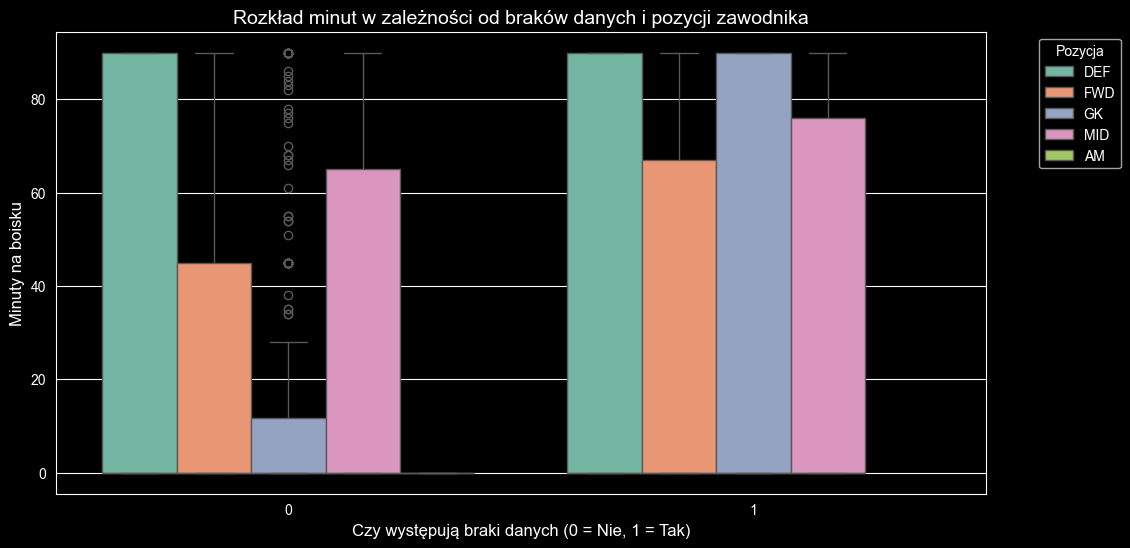

In [239]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=data_w_nan,
    x='nan_flag',
    y='minutes',
    hue='position',
    palette='Set2',
    orient="x"

)

plt.title("Rozkład minut w zależności od braków danych i pozycji zawodnika", fontsize=14)
plt.xlabel("Czy występują braki danych (0 = Nie, 1 = Tak)", fontsize=12)
plt.ylabel("Minuty na boisku", fontsize=12)

plt.legend(title='Pozycja', bbox_to_anchor=(1.05, 1), loc='upper left');


In [240]:
data_w_nan[(data_w_nan.position=="GK")].head()

,name,position,team,xp,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,gw,season_id,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,starts,modified,match_date,opp,gf,ga,sh,sht,corners,yc,rc,fouls,b365_win,b365_draw,b365_loss,b365_o25,b365_u25,b365_ah_line,b365_ah_team,b365_ah_opp,nan_flag
416,Aaron Ramsdale,GK,Arsenal,1.9,0,0,0,0,0.0,559,18,0,0,0.0,0.0,0,6,0,0,0,0,0,1432,2,0,0,0,597,679,82,45,True,0,2,2021-22,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2021-08-22,Chelsea,0,2,6,3,9,3,0,10,4.75,3.75,1.72,2.1,1.72,0.75,1.88,2.05,1
417,Aaron Ramsdale,GK,Arsenal,-0.5,0,0,0,0,0.0,559,24,0,0,0.0,0.0,0,12,0,0,0,0,0,8159,0,5,0,0,3141,4154,1013,45,False,0,3,2021-22,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2021-08-28,Man City,0,5,1,0,0,2,1,7,12.0,6.0,1.25,1.57,2.37,1.75,1.89,2.04,1
418,Aaron Ramsdale,GK,Arsenal,3.0,0,0,23,1,0.0,559,31,0,0,0.9,9.0,90,15,0,0,0,0,1,17374,0,1,0,6,6113,10225,4112,45,True,0,4,2021-22,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2021-09-11,Norwich,1,0,30,7,8,1,0,9,1.5,4.6,6.0,1.72,2.1,-1.0,1.85,2.08,1
419,Aaron Ramsdale,GK,Arsenal,4.8,0,2,32,1,0.0,559,43,0,0,2.6,26.4,90,5,0,0,0,0,3,77277,1,0,0,9,52488,65020,12532,45,False,0,5,2021-22,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2021-09-18,Burnley,1,0,13,3,3,1,0,8,1.95,3.6,3.8,2.0,1.8,-0.5,2.06,1.87,1
420,Aaron Ramsdale,GK,Arsenal,6.5,0,0,13,0,0.0,559,51,1,0,2.0,19.8,90,17,0,0,0,0,3,139625,1,3,0,3,55176,65509,10333,45,True,0,6,2021-22,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2021-09-26,Spurs,3,1,12,7,4,2,0,12,2.15,3.3,3.5,2.0,1.8,-0.25,1.96,1.97,1


In [241]:
data_w_nan[data_w_nan.position=="GK"][["expected_assists", "expected_goal_involvements", "expected_goals", "expected_goals_conceded"]].mean()

expected_assists              0.000376
expected_goal_involvements    0.000369
expected_goals                0.000029
expected_goals_conceded        0.32808
dtype: Float64

In [242]:
data_w_nan.loc[data_w_nan.position=="GK", ["expected_assists", "expected_goal_involvements", "expected_goals"] ] = data_w_nan.loc[data_w_nan.position=="GK", ["expected_assists", "expected_goal_involvements", "expected_goals"]].fillna(0)

In [243]:
data_w_nan.loc[data_w_nan.position.isin(["GK", "DEF"]), ["name", "position", "team"] + s[s<.2].index.to_list()]

,name,position,team,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,starts,b365_o25,b365_u25
0,Aaron Anselmino,DEF,Chelsea,0.0,0.0,0.0,0.0,0,1.57,2.38
1,Aaron Anselmino,DEF,Chelsea,0.0,0.0,0.0,0.0,0,1.57,2.38
2,Aaron Anselmino,DEF,Chelsea,0.0,0.0,0.0,0.0,0,1.29,3.75
3,Aaron Anselmino,DEF,Chelsea,0.0,0.0,0.0,0.0,0,1.33,3.2
4,Aaron Anselmino,DEF,Chelsea,0.0,0.0,0.0,0.0,0,1.86,1.92
...,...,...,...,...,...,...,...,...,...,...
127460,Łukasz Fabiański,GK,West Ham,0.0,0.0,0.0,0.0,0,1.67,2.2
127461,Łukasz Fabiański,GK,West Ham,0.0,0.0,0.0,0.0,0,1.57,2.38
127462,Łukasz Fabiański,GK,West Ham,0.0,0.0,0.0,0.0,0,1.73,2.1
127463,Łukasz Fabiański,GK,West Ham,0.0,0.0,0.0,0.0,0,1.98,1.92


Text(0, 0.5, 'Pozycja')

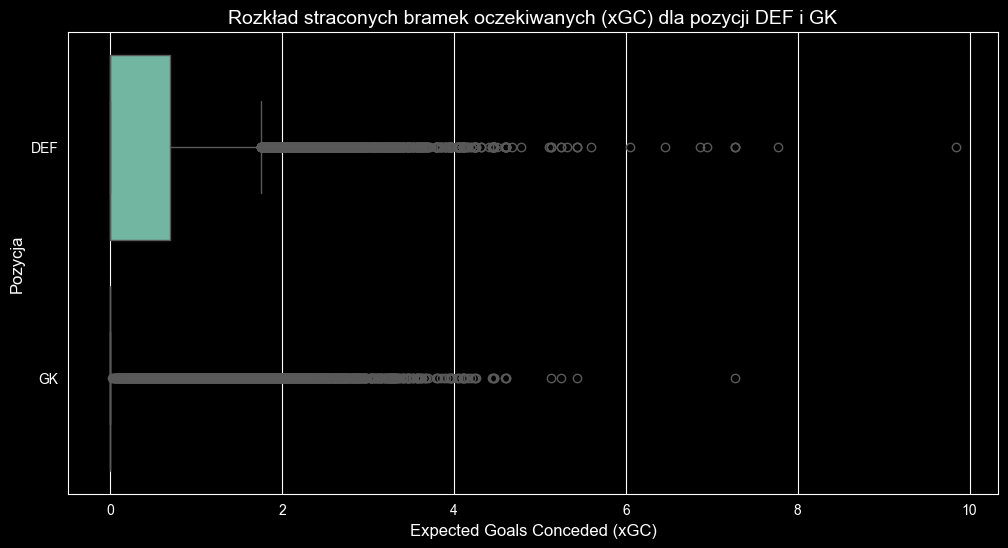

In [244]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=data_w_nan[data_w_nan['position'].isin(['DEF', 'GK'])],
    x="expected_goals_conceded",
    y="position",
    hue=data_w_nan[data_w_nan['position'].isin(['DEF', 'GK'])]["position"],
    palette='Set2',
    orient="y"

)

plt.title("Rozkład straconych bramek oczekiwanych (xGC) dla pozycji DEF i GK", fontsize=14)
plt.xlabel("Expected Goals Conceded (xGC)", fontsize=12)
plt.ylabel("Pozycja", fontsize=12)


In [245]:
def pos_imputation(df: pd.DataFrame, cols_to_impute: List[str]) -> pd.DataFrame:
    df = df.copy()

    df[cols_to_impute] = df[cols_to_impute].fillna(
        df.groupby(["season_id", "position", "team"])[cols_to_impute].transform("median")
    )

    df[cols_to_impute] = df[cols_to_impute].fillna(
        df.groupby("position")[cols_to_impute].transform("median")
    )

    return df

In [246]:
cols_to_impute = s[s<.2].index.to_list()
cols_to_impute = [c for c in cols_to_impute if "starts" not in c]
cols_to_impute

['expected_assists',
 'expected_goal_involvements',
 'expected_goals',
 'expected_goals_conceded',
 'b365_o25',
 'b365_u25']

In [247]:
data_w_nan = pos_imputation(df=data_w_nan,
                      cols_to_impute=cols_to_impute)

In [248]:
data_w_nan.expected_goals_conceded.isna().sum()

np.int64(0)

In [249]:
data_w_nan.isna().mean()[data_w_nan.isna().mean()>0]

starts      0.199639
modified    0.640780
dtype: float64

In [250]:
data_w_nan.starts.value_counts(normalize=True)


starts
0    0.731714
1    0.268286
Name: proportion, dtype: Float64

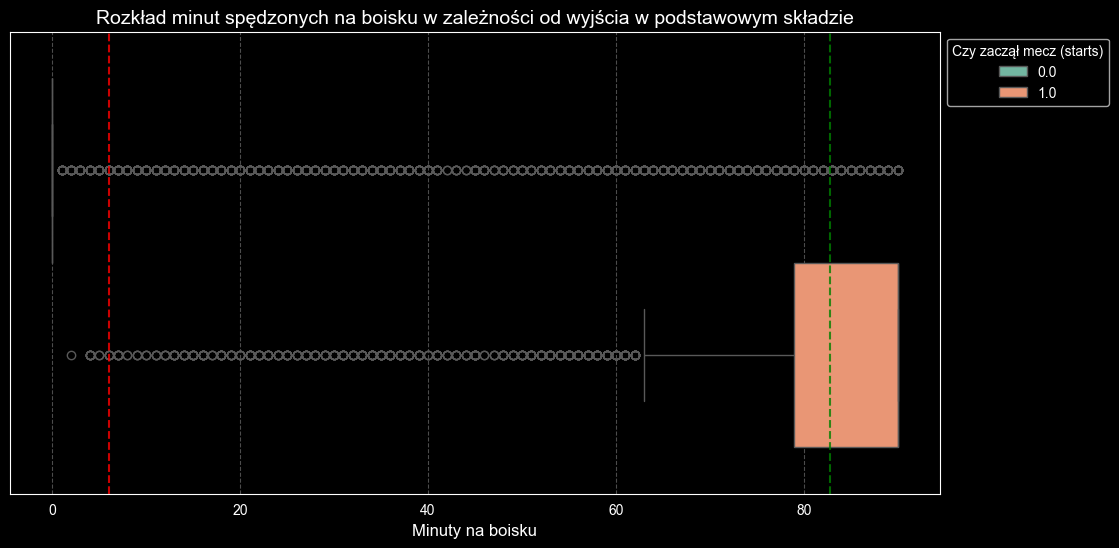

In [251]:
plt.figure(figsize=(12, 6))

ax = sns.boxplot(
    data=data_w_nan,
    x="minutes",
    hue="starts",
    palette='Set2'
)

plt.title("Rozkład minut spędzonych na boisku w zależności od wyjścia w podstawowym składzie", fontsize=14)
plt.xlabel("Minuty na boisku", fontsize=12)
sns.move_legend(ax, "upper left", title='Czy zaczął mecz (starts)', bbox_to_anchor=(1, 1))

ax.axvline(x=data_w_nan[data_w_nan.starts==0].minutes.mean(), color='r', linestyle='--', alpha=0.8)
ax.axvline(x=data_w_nan[data_w_nan.starts==1].minutes.mean(), color='g', linestyle='--', alpha=0.8)

plt.grid(axis='x', linestyle='--', alpha=0.3)

In [252]:
data_w_nan[data_w_nan.starts==0].minutes.mean(), data_w_nan[data_w_nan.starts==1].minutes.mean()

(np.float64(6.089674204265352), np.float64(82.73865546218488))

In [253]:
data_w_nan.loc[data.starts.isna(), ["name", "position", "team", "starts", "minutes"]].head()

,name,position,team,starts,minutes
14,Aaron Connolly,FWD,Brighton,<NA>,0
15,Aaron Connolly,FWD,Brighton,<NA>,45
16,Aaron Connolly,FWD,Brighton,<NA>,0
17,Aaron Connolly,FWD,Brighton,<NA>,0
18,Aaron Connolly,FWD,Brighton,<NA>,0


In [254]:
[data_w_nan.groupby('team')['starts'].apply(lambda x: x.isna().sum() == 0)]

[team
 Arsenal           False
 Aston Villa       False
 Bournemouth        True
 Brentford         False
 Brighton          False
 Burnley           False
 Chelsea           False
 Crystal Palace    False
 Everton           False
 Fulham             True
 Ipswich            True
 Leeds             False
 Leicester         False
 Liverpool         False
 Luton              True
 Man City          False
 Man Utd           False
 Newcastle         False
 Norwich           False
 Nott'm Forest      True
 Sheffield Utd      True
 Southampton       False
 Spurs             False
 Sunderland         True
 Watford           False
 West Ham          False
 Wolves            False
 Name: starts, dtype: bool]

In [255]:
data_w_nan.loc[data_w_nan['minutes'] == 0, 'starts'] = data_w_nan.loc[data_w_nan['minutes'] == 0, 'starts'].fillna(0)

In [256]:
data_w_nan.starts.isna().mean()

np.float64(0.0822578747107049)

In [257]:
data_w_nan[data_w_nan.starts.isna()]

,name,position,team,xp,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,gw,season_id,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,starts,modified,match_date,opp,gf,ga,sh,sht,corners,yc,rc,fouls,b365_win,b365_draw,b365_loss,b365_o25,b365_u25,b365_ah_line,b365_ah_team,b365_ah_opp,nan_flag
15,Aaron Connolly,FWD,Brighton,1.0,0,0,-2,0,1.1,72,12,0,0,0.5,0.0,45,18,0,0,0,0,0,15599,0,2,6,1,-1682,1899,3581,55,True,0,2,2021-22,0.0,0.0,0.0,0.0,<NA>,<NA>,2021-08-21,Watford,2,0,13,3,7,4,0,11,1.7,3.5,5.75,2.2,1.66,-0.75,1.98,1.95,1
19,Aaron Connolly,FWD,Brighton,0.3,0,0,2,0,0.3,72,54,0,0,0.1,0.2,14,7,0,0,0,0,0,9738,1,1,0,1,-232,1187,1419,53,False,0,6,2021-22,0.0,0.0,0.0,0.0,<NA>,<NA>,2021-09-27,Crystal Palace,1,1,8,4,5,3,0,10,2.45,3.2,3.1,2.3,1.61,-0.0,1.8,2.14,1
28,Aaron Connolly,FWD,Brighton,0.2,0,0,7,0,10.4,72,146,0,0,2.3,2.2,35,16,0,0,0,0,0,9181,1,1,10,1,91,720,629,53,False,0,15,2021-22,0.0,0.0,0.0,0.0,<NA>,<NA>,2021-12-04,Southampton,1,1,14,4,2,2,0,12,3.0,3.2,2.45,2.2,1.66,0.25,1.83,2.07,1
29,Aaron Connolly,FWD,Brighton,0.6,0,0,5,0,1.3,72,163,1,0,0.2,0.0,60,20,0,0,0,0,0,9319,1,0,2,2,240,736,496,53,True,0,17,2021-22,0.0,0.0,0.0,0.0,<NA>,<NA>,2021-12-15,Wolves,0,1,12,2,7,2,0,11,2.25,3.1,3.5,2.5,1.53,-0.25,2.0,1.9,1
90,Aaron Cresswell,DEF,West Ham,3.6,0,0,30,0,17.5,411,9,2,1,9.1,55.8,90,14,0,0,0,0,0,1213434,4,2,18,7,0,0,0,55,False,0,1,2021-22,0.0,0.0,0.0,0.0,<NA>,<NA>,2021-08-15,Newcastle,4,2,8,9,6,0,0,3,2.2,3.5,3.2,1.99,1.94,-0.25,1.99,1.94,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127273,Çaglar Söyüncü,DEF,Leicester,2.9,0,0,18,0,0.3,217,293,1,0,3.0,29.4,90,3,0,0,0,0,0,210539,1,2,0,2,15236,21205,5969,49,True,0,30,2021-22,0.0,0.0,0.0,0.0,<NA>,<NA>,2022-03-20,Brentford,2,1,12,4,2,1,0,10,2.15,3.4,3.4,1.91,1.99,-0.25,1.88,2.02,1
127275,Çaglar Söyüncü,DEF,Leicester,1.0,0,0,15,0,10.9,217,315,1,0,3.6,22.6,90,7,0,0,0,0,0,149718,1,2,2,2,1853,4409,2556,49,True,0,32,2021-22,0.0,0.0,0.0,0.0,<NA>,<NA>,2022-04-10,Crystal Palace,2,1,12,3,3,1,0,11,2.37,3.3,2.9,1.99,1.91,-0.25,2.09,1.81,1
127276,Çaglar Söyüncü,DEF,Leicester,2.1,0,0,13,0,0.4,217,325,2,0,1.1,10.4,90,14,0,0,0,0,0,180861,1,2,0,1,24526,26626,2100,49,False,0,33,2021-22,0.0,0.0,0.0,0.0,<NA>,<NA>,2022-04-17,Newcastle,1,2,8,2,5,2,0,10,3.3,3.4,2.2,1.99,1.91,0.25,1.95,1.95,1
127278,Çaglar Söyüncü,DEF,Leicester,2.4,0,3,30,1,0.8,217,337,0,0,2.0,19.4,90,2,0,0,0,0,0,170925,0,0,0,9,-3439,4322,7761,49,True,0,34,2021-22,0.0,0.0,0.0,0.0,<NA>,<NA>,2022-04-23,Aston Villa,0,0,5,2,7,3,0,15,2.8,3.4,2.5,1.85,2.05,0.0,2.06,1.84,1


In [258]:
data_w_nan.loc[data_w_nan['starts'].isna(), "starts"] = (data_w_nan['minutes'] > 60).astype(int)

In [259]:
data_w_nan.starts.isna().mean()

np.float64(0.0)

In [260]:
data_w_nan.shape

(127465, 60)

In [261]:
data_w_nan.isna().mean()[data_w_nan.isna().mean()>0]

modified    0.64078
dtype: float64

In [270]:
data_w_nan.drop(columns=["modified"], inplace=True)

In [271]:
data_w_nan.isna().sum().sum()

np.int64(0)

In [272]:
data_w_nan.duplicated().sum()

np.int64(10)

In [274]:
data_w_nan[data_w_nan.duplicated(keep=False)]

,name,position,team,xp,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,gw,season_id,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,starts,match_date,opp,gf,ga,sh,sht,corners,yc,rc,fouls,b365_win,b365_draw,b365_loss,b365_o25,b365_u25,b365_ah_line,b365_ah_team,b365_ah_opp,nan_flag
12461,Ben Gannon-Doak,MID,Liverpool,0.5,0,0,0,0,0.0,391,1,0,0,0.0,0.0,0,4,0,0,0,0,0,4207,2,4,0,0,0,0,0,50,True,0,1,2025-26,0.0,0.0,0.0,0.0,0,2025-08-15,Bournemouth,4,2,19,10,6,1,0,7,1.3,6.0,8.5,1.36,3.2,-1.5,1.83,2.03,0
12462,Ben Gannon-Doak,MID,Liverpool,0.5,0,0,0,0,0.0,391,1,0,0,0.0,0.0,0,4,0,0,0,0,0,4207,2,4,0,0,0,0,0,50,True,0,1,2025-26,0.0,0.0,0.0,0.0,0,2025-08-15,Bournemouth,4,2,19,10,6,1,0,7,1.3,6.0,8.5,1.36,3.2,-1.5,1.83,2.03,0
65907,Junior Kroupi,FWD,Bournemouth,0.0,0,0,2,0,0.0,100,1,1,0,0.0,0.0,1,12,0,0,0,0,0,85883,2,4,0,1,0,0,0,45,False,0,1,2025-26,0.0,0.0,0.0,0.11,0,2025-08-15,Liverpool,2,4,10,3,7,2,0,10,8.5,6.0,1.3,1.36,3.2,1.5,2.03,1.83,0
65908,Junior Kroupi,FWD,Bournemouth,0.0,0,0,2,0,0.0,100,1,1,0,0.0,0.0,1,12,0,0,0,0,0,85883,2,4,0,1,0,0,0,45,False,0,1,2025-26,0.0,0.0,0.0,0.11,0,2025-08-15,Liverpool,2,4,10,3,7,2,0,10,8.5,6.0,1.3,1.36,3.2,1.5,2.03,1.83,0
65909,Junior Kroupi,FWD,Bournemouth,1.0,0,0,3,0,0.0,100,12,0,0,0.2,0.0,2,20,0,0,0,0,0,146695,0,1,2,1,28243,48171,19928,45,True,0,2,2025-26,0.0,0.0,0.0,0.06,0,2025-08-23,Wolves,1,0,14,4,8,2,0,13,1.8,3.8,4.2,1.73,2.1,-0.75,2.03,1.83,0
65910,Junior Kroupi,FWD,Bournemouth,1.0,0,0,3,0,0.0,100,12,0,0,0.2,0.0,2,20,0,0,0,0,0,146695,0,1,2,1,28243,48171,19928,45,True,0,2,2025-26,0.0,0.0,0.0,0.06,0,2025-08-23,Wolves,1,0,14,4,8,2,0,13,1.8,3.8,4.2,1.73,2.1,-0.75,2.03,1.83,0
65911,Junior Kroupi,FWD,Bournemouth,1.0,0,0,3,0,0.0,100,29,0,0,0.0,0.0,9,18,0,0,0,0,0,130246,1,0,0,1,-15048,20512,35560,45,False,0,3,2025-26,0.0,0.0,0.0,0.07,0,2025-08-30,Spurs,1,0,20,6,8,4,0,13,4.2,4.2,1.73,1.57,2.38,0.75,1.9,1.95,0
65912,Junior Kroupi,FWD,Bournemouth,1.0,0,0,3,0,0.0,100,29,0,0,0.0,0.0,9,18,0,0,0,0,0,130246,1,0,0,1,-15048,20512,35560,45,False,0,3,2025-26,0.0,0.0,0.0,0.07,0,2025-08-30,Spurs,1,0,20,6,8,4,0,13,4.2,4.2,1.73,1.57,2.38,0.75,1.9,1.95,0
65913,Junior Kroupi,FWD,Bournemouth,0.7,0,0,0,0,0.0,100,32,0,0,0.0,0.0,0,6,0,0,0,0,0,148264,1,2,0,0,8520,38988,30468,45,True,0,4,2025-26,0.0,0.0,0.0,0.0,0,2025-09-13,Brighton,2,1,13,5,4,4,0,16,2.35,3.5,2.9,1.67,2.2,-0.25,2.05,1.8,0
65914,Junior Kroupi,FWD,Bournemouth,0.7,0,0,0,0,0.0,100,32,0,0,0.0,0.0,0,6,0,0,0,0,0,148264,1,2,0,0,8520,38988,30468,45,True,0,4,2025-26,0.0,0.0,0.0,0.0,0,2025-09-13,Brighton,2,1,13,5,4,4,0,16,2.35,3.5,2.9,1.67,2.2,-0.25,2.05,1.8,0


In [275]:
data.drop_duplicates(keep="first", inplace=True)

In [276]:
cleaned_cols = data_w_nan.columns.to_list()

In [277]:
data = data_w_nan.drop(columns="nan_flag").copy()

In [278]:
data.shape

(127465, 58)

In [279]:
filename = "../../Data/FPL_data_tidy.parquet"
data.to_parquet(filename,
                engine='pyarrow',
                index=False)